### Lab 4 – LINEAR REGRESSION  

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/farhanmd29/50-startups/50_Startups.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/datasets/farhanmd29/50-startups/50_Startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


## Simple Linear Regression (Using sklearn)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
X = df[['R&D Spend']]
Y = df['Profit']

In [7]:
#Train Test Split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [8]:
#Train Model

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [9]:
Y_pred = model.predict(X_test)

In [10]:
#Evaluation

print("MSE:",mean_squared_error(Y_test,Y_pred))
print("R2 Score:",r2_score(Y_test,Y_pred))

MSE: 59510962.80787997
R2 Score: 0.9265108109341951


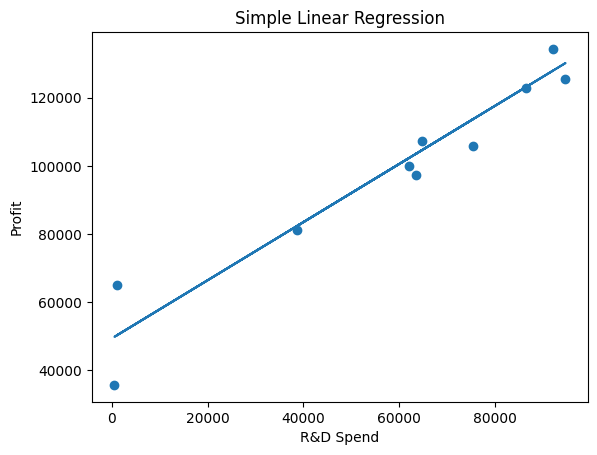

In [11]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,Y_pred)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Simple Linear Regression")
plt.show()

## Multiple Linear Regression (Using sklearn)

In [12]:
X = df[['R&D Spend','Administration','Marketing Spend']]
y = df['Profit']

In [13]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("MSE:", mean_squared_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))

MSE: 59510962.80787997
R2 Score: 0.9265108109341951


## Simple Linear Regression (Without Sklearn)

In [16]:
x = df["R&D Spend"].values
y = df["Profit"].values

In [17]:
mean_x = np.mean(x)
mean_y = np.mean(y)

numerator = np.sum((x - mean_x) * (y - mean_y))
denominator = np.sum((x - mean_x) ** 2)

b1 = numerator / denominator
b0 = mean_y - b1 * mean_x

print("Intercept:", b0)
print("Slope:", b1)

Intercept: 49032.89914125215
Slope: 0.8542913709388087


In [18]:
#Prediction
y_pred = b0 + b1 * x

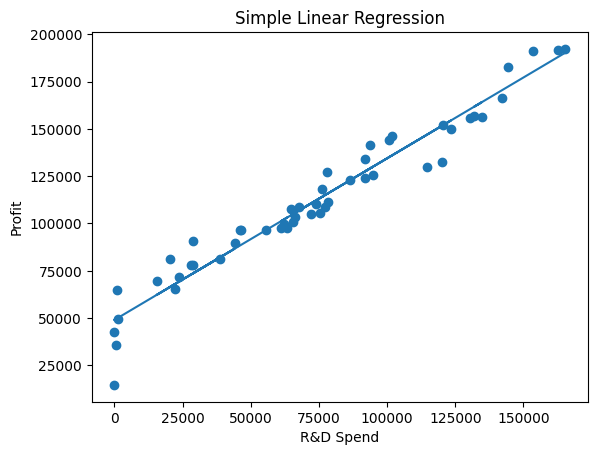

In [19]:
plt.scatter(x, y)
plt.plot(x, y_pred)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Simple Linear Regression")
plt.show()

## MULTIPLE LINEAR REGRESSION WITHOUT SKLEARN

In [20]:
X = df[["R&D Spend","Administration","Marketing Spend"]].values
y = df["Profit"].values

In [21]:
#Add Bias Column
ones = np.ones((X.shape[0],1))
X = np.hstack((ones, X))

In [22]:
beta = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)

print("Coefficients:", beta)

Coefficients: [ 5.01221930e+04  8.05715050e-01 -2.68159687e-02  2.72280647e-02]


## GRADIENT DESCENT IMPLEMENTATION

In [23]:
X = df["R&D Spend"].values
y = df["Profit"].values

In [24]:
# Normalize feature
X = (X - X.mean()) / X.std()

#Initialize Parameters

m = 0
b = 0

learning_rate = 0.001
epochs = 1000
n = len(X)

In [25]:
#Gradient Descent Loop

for i in range(epochs):

    y_pred = m*X + b

    dm = (-2/n) * np.sum(X*(y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    m = m - learning_rate*dm
    b = b - learning_rate*db

In [26]:
#Final Parameters

print("Slope:", m)
print("Intercept:", b)

Slope: 33576.606728231935
Intercept: 96883.70557845943


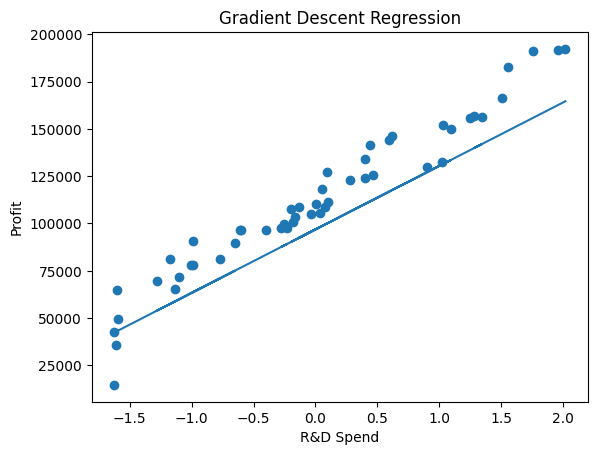

In [27]:
plt.scatter(X,y)
plt.plot(X, m*X + b)
plt.xlabel("R&D Spend")
plt.ylabel("Profit")
plt.title("Gradient Descent Regression")
plt.show()